# Backtesting checks

In [12]:
import sys
import math
import numpy as np

from tools import ROOT

# Пакет backtesting лежит в корне репо (research/ на пути только для tools).
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from backtesting.lighter import Strategy, Backtester, OrderBook, LighterFeed
from backtesting.lighter.instruments.visualize import BacktestResult

CAPITAL = 5000.0  # USD

In [13]:
class AvellanedaStoikov(Strategy):
    def __init__(self, sigma, kappa, gamma, T, Q):
        self.gamma   = gamma
        self.T       = T
        self._sigma2 = sigma ** 2
        self.Q = Q
        self._half_log_term = (1.0 / gamma) * math.log(1.0 + gamma / kappa)
        self._t0_us  = None

    def on_lob(self, ob: OrderBook, inventory: float):
        if self._t0_us is None:
            self._t0_us = ob.timestamp_us
        tau = max(0.0, self.T - ((ob.timestamp_us - self._t0_us) / 1e6 % self.T))

        risk_term   = self.gamma * self._sigma2 * tau
        r           = ob.mid - inventory * risk_term
        half_spread = 0.5 * risk_term + self._half_log_term
        return [
            ("bid", r - half_spread, self.Q),
            ("ask", r + half_spread, self.Q),
        ]

In [14]:
hours = range(0, 24)  # 3 часа DOGE — быстрый прогон; расширь диапазон при желании
lob_paths    = [ROOT / f"data/lighter/DOGE/lob/20260712/{h:02d}.parquet"      for h in hours]
trades_paths = [ROOT / f"data/lighter/DOGE/trades/20260712/{h:02d}.jsonl.zst" for h in hours]

feed = LighterFeed(lob_paths, trades_paths)
feed

LighterFeed(lob=280,858 snapshots [2026-07-12 00:00:00.042000 → 2026-07-12 23:59:59.746000], trades=1,093 [2026-07-12 00:00:31.945000 → 2026-07-12 23:56:08.242000])

In [15]:
def check_feed(f):
    assert f.lob_ts.dtype == np.int64 and f.trade_ts.dtype == np.int64
    assert f.bid_px.shape[1] == f.ask_px.shape[1], "level count mismatch"
    assert (np.diff(f.lob_ts)   >= 0).all(), "LOB timestamps not sorted"
    assert (np.diff(f.trade_ts) >= 0).all(), "trade timestamps not sorted"
    assert set(np.unique(f.trade_is_sell)).issubset({0, 1})

    best_bid, best_ask = f.bid_px[:, 0], f.ask_px[:, 0]
    crossed = int((best_ask <= best_bid).sum())
    print(f"levels        : {f.bid_px.shape[1]}")
    print(f"lob snapshots : {len(f.lob_ts):,}  (crossed/locked: {crossed})")
    print(f"trades        : {len(f.trade_ts):,}  (sells: {int(f.trade_is_sell.sum()):,})")
    print("invariants OK")

check_feed(feed)

levels        : 30
lob snapshots : 280,858  (crossed/locked: 0)
trades        : 1,093  (sells: 629)
invariants OK


In [16]:
# PnL пока не показателен: без комиссий/латентности/tick-rounding (следующие итерации).
# Цель прогона — движок гоняется на реальных данных Lighter и инварианты держатся.
params = {"sigma": 1e-06, "kappa": 1e6, "gamma": 0.01, "T": 14400.0, "Q": 100.0}
prefix = "/tmp/_lighter_dod"

bt = Backtester(log_interval_sec=10.0)
bt.run(AvellanedaStoikov(**params), feed=feed, output_path=prefix)

'/tmp/_lighter_dod'

In [17]:
s = BacktestResult(prefix, capital=CAPITAL)
display(s.summary_df())

value
group     metric                       
PnL       total_pnl ($)         -5.7568
          total_pnl (%)        -0.1151%
          sharpe_annualized      -27.10
          max_drawdown ($)      -7.4511
          max_drawdown (%)     -0.1490%
Fills     n_fills                   693
          n_bid_fills               352
          n_ask_fills               341
          fill_imbalance        +0.0159
Inventory avg_inventory      -2037.6023
          std_inventory       2693.1766
          max_abs_inventory   4907.0000
          turnover ($)         4,952.12

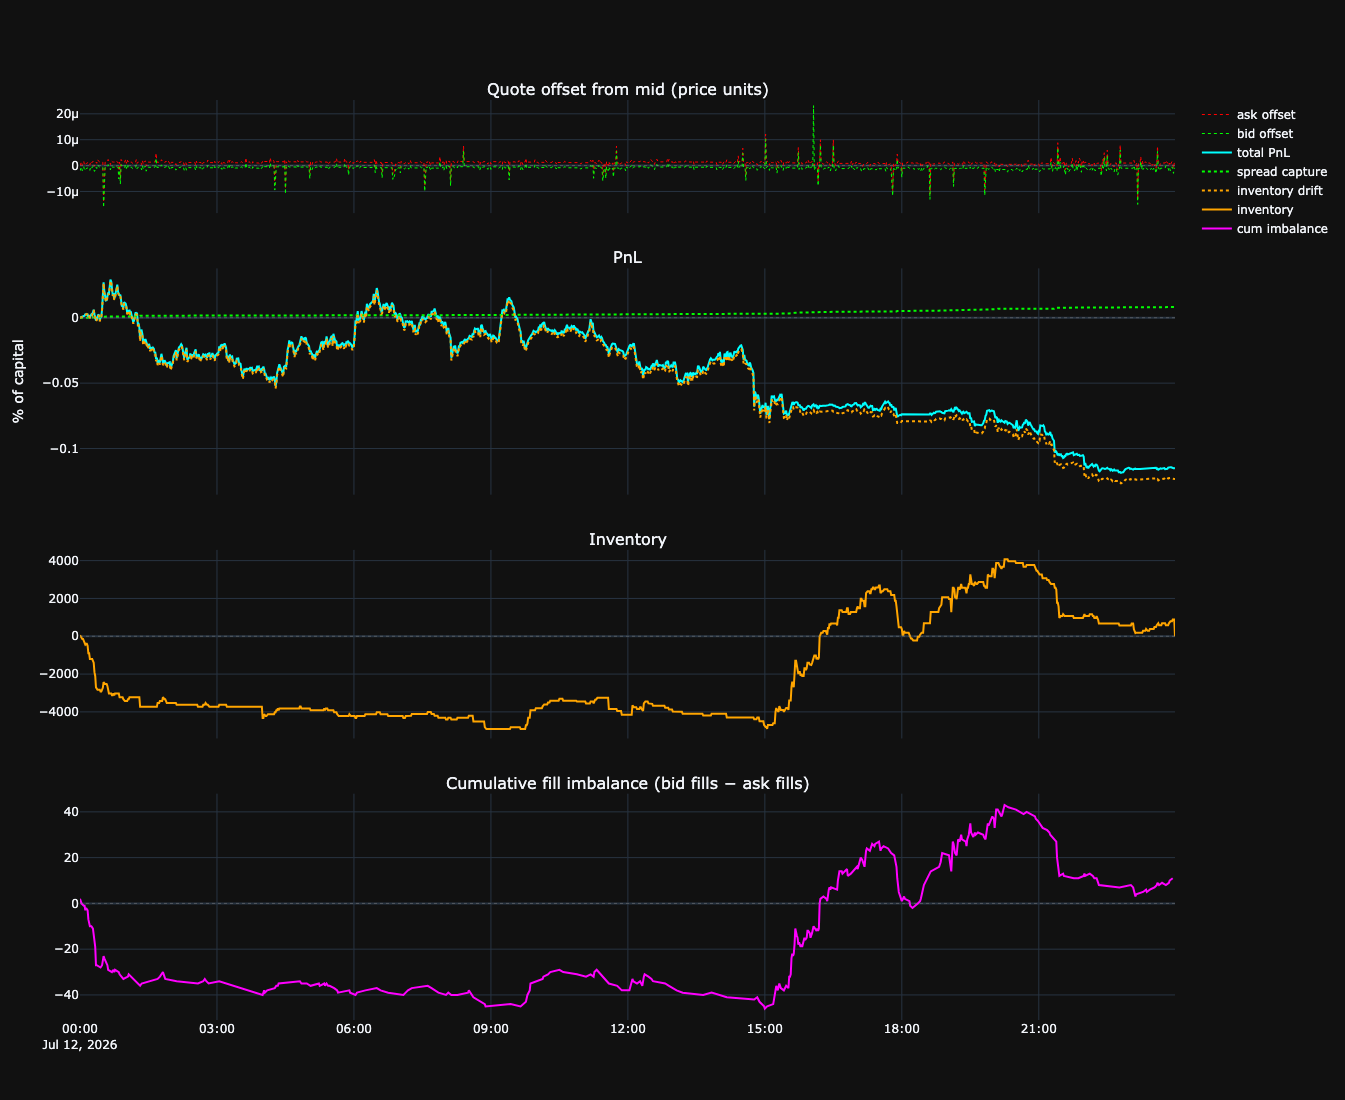

In [18]:
s.plot().show()   # tick_size не задаю: тик DOGE на Lighter — UNVERIFIED, оси в price units

### Проверки корректности движка (latency + мультиуровень)

Синтетические сценарии (A–C) с заранее известным ответом — изолируют логику матчинга и latency.
Инварианты на реальных данных (D–G) — монотонность, голодание, детерминизм, сходимость PnL.
Каждая ячейка печатает `OK`; при нарушении падает по `assert`. Опираются на `feed` и `params` выше.

In [19]:
from backtesting.lighter import LOB_LEVELS


class ArrayFeed:
    """Minimal in-memory feed (same .arrays() contract as LighterFeed) for tests."""
    def __init__(self, arrays):
        self._arrays = arrays
    def arrays(self):
        return self._arrays


def make_feed(snaps, trades):
    """Build a tiny feed from top-of-book rows.
    snaps:  (ts, bid_px, bid_sz, ask_px, ask_sz)   — only level 1 is set, rest zero
    trades: (ts, is_sell, price, size)
    """
    n = len(snaps)
    bid_px, bid_sz = np.zeros((n, LOB_LEVELS)), np.zeros((n, LOB_LEVELS))
    ask_px, ask_sz = np.zeros((n, LOB_LEVELS)), np.zeros((n, LOB_LEVELS))
    for i, (_, bp, bs, ap, asz) in enumerate(snaps):
        bid_px[i, 0], bid_sz[i, 0] = bp, bs
        ask_px[i, 0], ask_sz[i, 0] = ap, asz
    return ArrayFeed(dict(
        lob_ts=np.array([s[0] for s in snaps], np.int64),
        bid_px=bid_px, bid_sz=bid_sz, ask_px=ask_px, ask_sz=ask_sz,
        trade_ts=np.array([t[0] for t in trades], np.int64),
        trade_is_sell=np.array([t[1] for t in trades], np.uint8),
        trade_price=np.array([t[2] for t in trades], np.float64),
        trade_size=np.array([t[3] for t in trades], np.float64),
    ))


class FixedQuotes(Strategy):
    """Quotes a fixed set every tick (ignores the book) — for deterministic tests."""
    def __init__(self, quotes):
        self._quotes = quotes
    def on_lob(self, ob, inventory):
        return list(self._quotes)


class ASLadder(Strategy):
    """Avellaneda–Stoikov, quoting n_levels each side spaced `step` apart."""
    def __init__(self, sigma, kappa, gamma, T, Q, n_levels=3, step=2e-6):
        self.gamma, self.T, self._sigma2, self.Q = gamma, T, sigma ** 2, Q
        self.n_levels, self.step = n_levels, step
        self._half_log_term = (1.0 / gamma) * math.log(1.0 + gamma / kappa)
        self._t0_us = None

    def on_lob(self, ob, inventory):
        if self._t0_us is None:
            self._t0_us = ob.timestamp_us
        tau = max(0.0, self.T - ((ob.timestamp_us - self._t0_us) / 1e6 % self.T))
        risk = self.gamma * self._sigma2 * tau
        r = ob.mid - inventory * risk
        half = 0.5 * risk + self._half_log_term
        orders = []
        for i in range(self.n_levels):
            off = half + i * self.step
            orders += [("bid", r - off, self.Q), ("ask", r + off, self.Q)]
        return orders


def run_result(strat, feed, latency_us, tag):
    prefix = f"/tmp/_chk_{tag}"
    Backtester(latency_us=latency_us, log_interval_sec=10.0).run(strat, feed=feed, output_path=prefix)
    return BacktestResult(prefix, capital=CAPITAL)

In [20]:
# ── A. latency gating: an order must not fill before it lands ──
#    bid@100 size5; sell@100 size100 at t=100. queue at 100 is 10 → fill = min(5, 100-10) = 5.
feed_a = make_feed([(0, 100.0, 10.0, 101.0, 10.0)],
                   [(100, 1, 100.0, 100.0)])
a0 = run_result(FixedQuotes([("bid", 100.0, 5.0)]), feed_a, 0,   "a0")   # lands at t=0 → fills
a9 = run_result(FixedQuotes([("bid", 100.0, 5.0)]), feed_a, 200, "a9")   # lands at t=200 > trade → no fill
assert a0.summary()["n_fills"] == 1
assert abs(a0.fills[a0.fills["side"] == "bid"]["size"].iloc[0] - 5.0) < 1e-9
assert a9.summary()["n_fills"] == 0
print(f"A gating      : fills(lat=0)={a0.summary()['n_fills']}  fills(lat=200)={a9.summary()['n_fills']}  OK")

# ── B. multi-level: independent fills at several price levels ──
#    bid@100 and bid@99; a sell@99 reaches both. queue: 1 at 100, 0 at 99 → both fill fully (5 each).
feed_b = make_feed([(0, 100.0, 1.0, 101.0, 1.0)],
                   [(100, 1, 99.0, 100.0)])
b = run_result(FixedQuotes([("bid", 100.0, 5.0), ("bid", 99.0, 5.0)]), feed_b, 0, "b")
b_prices = sorted(round(p, 6) for p in b.fills[b.fills["side"] == "bid"]["price"])
assert b.summary()["n_fills"] == 2 and b_prices == [99.0, 100.0]
print(f"B multilevel  : n_fills={b.summary()['n_fills']}  prices={b_prices}  OK")

# ── C. partial fill: only (trade − queue ahead) fills; remainder rests ──
#    bid@100 size10; sell@100 size7 with queue 5 ahead → fill = 7 - 5 = 2.
feed_c = make_feed([(0, 100.0, 5.0, 101.0, 5.0)],
                   [(100, 1, 100.0, 7.0)])
c = run_result(FixedQuotes([("bid", 100.0, 10.0)]), feed_c, 0, "c")
c_size = c.fills[c.fills["side"] == "bid"]["size"].iloc[0]
assert c.summary()["n_fills"] == 1 and abs(c_size - 2.0) < 1e-9
print(f"C partial     : fill_size={c_size}  (expected 2.0)  OK")

A gating      : fills(lat=0)=1  fills(lat=200)=0  OK
B multilevel  : n_fills=2  prices=[99.0, 100.0]  OK
C partial     : fill_size=2  (expected 2.0)  OK


In [21]:
# ── D. latency delays fills — controlled monotone case ──
#    One resting bid (queue 0 → fills on any sell); four sells at 500..3500 µs.
#    Latency L blanks the lead-in [0, L): a trade fills only once an order has landed,
#    so each 1000-µs step of latency knocks out exactly one more trade.
snaps  = [(t, 100.0, 0.0, 101.0, 1.0) for t in range(0, 5000, 1000)]
sells  = [(t, 1, 100.0, 1.0) for t in (500, 1500, 2500, 3500)]
feed_d = make_feed(snaps, sells)
n_by_lat = [run_result(FixedQuotes([("bid", 100.0, 1.0)]), feed_d, L, f"dsyn{L}").summary()["n_fills"]
            for L in (0, 1000, 2000, 3000)]
assert n_by_lat == [4, 3, 2, 1], f"expected [4, 3, 2, 1], got {n_by_lat}"
print(f"D monotone    : fills per latency {n_by_lat}  (each step blanks one more trade)  OK")

# ── D2 (diagnostic, no assert): real-data sweep is NOT monotone by design ──
#    ASLadder quotes ~1e-6 from mid — deep inside the ~3.5e-5 DOGE spread — on prices
#    absent from the book, where queue_ahead is 0 and any through-trade fills. Its price
#    also MOVES with latency, so stale near-mid quotes get adversely selected and fills
#    can RISE with latency (worse PnL, more fills). Expected, not a bug.
for lat in [0, 1_000, 10_000, 100_000, 1_000_000]:
    n = run_result(ASLadder(**params), feed, lat, f"d{lat}").summary()["n_fills"]
    print(f"latency={lat:>9} µs   n_fills={n:>6}")

# ── E. latency beyond the data span: nothing ever lands → zero fills ──
span = int(max(feed.lob_ts[-1], feed.trade_ts[-1]) - min(feed.lob_ts[0], feed.trade_ts[0]))
e = run_result(ASLadder(**params), feed, span + 1_000_000, "e")
assert e.summary()["n_fills"] == 0
print(f"E starved     : latency>span → n_fills={e.summary()['n_fills']}  OK")

D monotone    : fills per latency [4, 3, 2, 1]  (each step blanks one more trade)  OK
latency=        0 µs   n_fills=  1911
latency=     1000 µs   n_fills=  1911
latency=    10000 µs   n_fills=  1916
latency=   100000 µs   n_fills=  1933
latency=  1000000 µs   n_fills=  1846
E starved     : latency>span → n_fills=0  OK


In [22]:
# ── F. determinism: identical inputs → identical output ──
f1 = run_result(ASLadder(**params), feed, 10_000, "f1")
f2 = run_result(ASLadder(**params), feed, 10_000, "f2")
assert f1.fills.reset_index(drop=True).equals(f2.fills.reset_index(drop=True))
assert np.allclose(f1.pnl.values, f2.pnl.values)
print("F determinism : two identical runs match  OK")

# ── G. PnL accounting: reconstruct final PnL from fills, compare to reported ──
def final_pnl_from_fills(r):
    f = r.fills
    tr = f[f["side"].isin(["bid", "ask"])]
    cash = float((np.where(tr["side"] == "ask", 1.0, -1.0) * tr["price"] * tr["size"]).sum())
    inv  = float((np.where(tr["side"] == "bid", 1.0, -1.0) * tr["size"]).sum())
    mk = f[f["side"] == "markout"]
    assert abs(mk["size"].iloc[-1] + inv) < 1e-6, "markout must close net inventory"
    return cash + inv * float(mk["price"].iloc[-1])

recon    = final_pnl_from_fills(f1)
reported = float(f1.pnl.iloc[-1])
assert abs(recon - reported) <= 1e-6 * max(1.0, abs(reported))
print(f"G accounting  : reconstructed={recon:+.6f}  reported={reported:+.6f}  OK")

F determinism : two identical runs match  OK
G accounting  : reconstructed=-9.097931  reported=-9.097931  OK
